# Outfit Compatiblity Rater


## Imports

In [168]:
# %pip install -r requirements.txt

In [169]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, confusion_matrix

import seaborn as sns

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch
import torch.nn.functional as F

## Data Cleaning & Preprocessing

#### Load Data

In [170]:
# Compatibility labels
with open('polyvore/fashion_compatibility_prediction.txt', 'r') as f:
    lines = f.readlines()
    
# Load and combine JSON files
with open('polyvore/train_no_dup.json', 'r') as f:
    train_data = json.load(f)
with open('polyvore/test_no_dup.json', 'r') as f:
    test_data = json.load(f)
with open('polyvore/valid_no_dup.json', 'r') as f:
    valid_data = json.load(f)

all_outfits = train_data + test_data + valid_data

#### Build Lookup Tables

In [171]:
# Image lookup 
image_lookup = {}
for category in os.listdir('images/Re-PolyVore'):
    category_path = f'images/Re-PolyVore/{category}'
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.endswith('.jpg'):
                item_id = filename.replace('.jpg', '')
                image_lookup[item_id] = f'{category_path}/{filename}'

# Name lookup
name_lookup = {}
for outfit in all_outfits:
    set_id = outfit['set_id']
    for item in outfit['items']:
        item_id = f"{set_id}_{item['index']}"
        name_lookup[item_id] = item['name']

#### Visualize Example Outfit

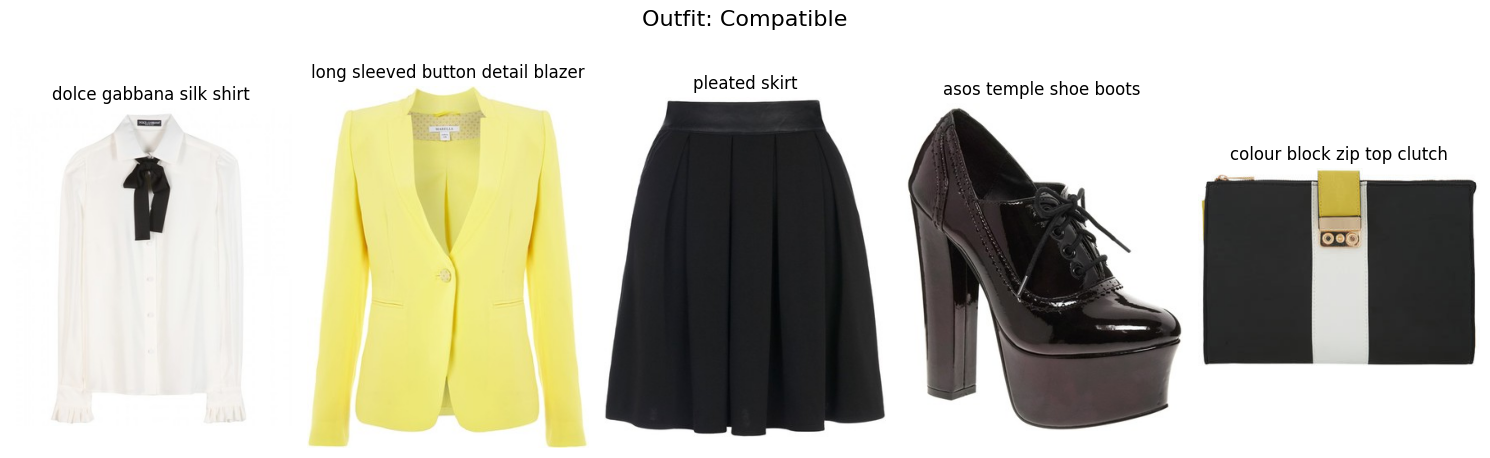

In [172]:
first_outfit = lines[0].strip().split()
label = first_outfit[0]
items = first_outfit[1:]

fig, axes = plt.subplots(1, len(items), figsize=(15, 5))

for i, item_id in enumerate(items):
    if item_id in image_lookup:
        img = Image.open(image_lookup[item_id])
        axes[i].imshow(img)
        name = name_lookup.get(item_id, 'Unknown')
        axes[i].set_title(name, fontsize=12, wrap=True)
        axes[i].axis('off')
    else:
        print(f"Missing: {item_id}")

label_text = "Compatible" if label == '1' else "Incompatible"
plt.suptitle(f"Outfit: {label_text}", fontsize=16)
plt.tight_layout()
plt.show()

#### Data Cleaning

In [173]:
# Analyze data
total = 0
zero_items = 0
one_item = 0
two_items = 0
three_items = 0
four_plus_items = 0

for line in lines:
    parts = line.strip().split()
    if len(parts) < 2:
        continue
    
    item_ids = parts[1:]
    available = sum(1 for id in item_ids if id in image_lookup)
    total += 1
    
    if available == 0:
        zero_items += 1
    elif available == 1:
        one_item += 1
    elif available == 2:
        two_items += 1
    elif available == 3:
        three_items += 1
    else:
        four_plus_items += 1

print(f"Total outfits: {total}")
print(f"─────────────────────────────")
print(f"0 images found: {zero_items} outfits ← will be removed")
print(f"1 image found:  {one_item} outfits ← will be removed")
print(f"2 images found: {two_items} outfits ← will be kept")
print(f"3 images found: {three_items} outfits ← will be kept")
print(f"4+ images found: {four_plus_items} outfits ← will be kept")
print(f"─────────────────────────────")
print(f"Total removed: {zero_items + one_item}")
print(f"Total kept: {two_items + three_items + four_plus_items}")

Total outfits: 7076
─────────────────────────────
0 images found: 752 outfits ← will be removed
1 image found:  780 outfits ← will be removed
2 images found: 1409 outfits ← will be kept
3 images found: 1639 outfits ← will be kept
4+ images found: 2496 outfits ← will be kept
─────────────────────────────
Total removed: 1532
Total kept: 5544


In [174]:
# Filter to complete outfits (2 or more items)
lines = [
    line for line in lines
    if len(line.strip().split()) >= 2
    and sum(1 for id in line.strip().split()[1:] if id in image_lookup) >= 2
]

#### Preprocessing 

In [175]:
# Load ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
base_model.trainable = False

In [176]:
# Embedding Functions

# Each clothing item image is converted to a 2048-dimensional
# feature vector using ResNet50, then L2 normalized to ensure
# consistent feature scaling across all items.

# Two outfit embedding strategies are provided:
#   1. get_outfit_embedding: concatenation + mean (10240-dimensional)
#   2. get_outfit_pairwise_embedding: concatenation + mean + pairwise 
#      differences (22528-dimensional)

def get_item_embedding(item_id):
    """
    Converts a single clothing item image into a normalized numerical 
    representation using the pretrained ResNet50 model.
    
    L2 normalization is applied to ensure consistent feature scaling
    across all items regardless of image brightness or contrast.
    All item embeddings have magnitude of 1, preventing large values
    from dominating the classifier.
        
    Parameters:
        item_id (str): The unique identifier for the clothing item, 
            such as '119704139_1'
    Returns:
        numpy array of shape (2048,): A normalized vector of 2048 numbers 
            describing the visual features of the clothing item such as
            color, texture, and style.
    """
    img_path = image_lookup[item_id]
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    embedding = base_model.predict(img_array, verbose=0)[0]
    
    # L2 normalize: divide by magnitude so all embeddings
    # have consistent scale regardless of image properties
    norm = np.linalg.norm(embedding)
    if norm > 0:
        embedding = embedding / norm
    
    return embedding


def get_outfit_embedding(item_ids, max_items=4):
    """
    Converts a full outfit into a fixed-size numerical representation
    using concatenation + mean strategy.

    Preserves individual item information by concatenating each item's
    normalized embedding, while capturing overall outfit context through
    a global mean embedding.

    Parameters:
        item_ids (list): List of item ID strings for this outfit,
            such as ['119704139_1', '119704139_2', '119704139_3']
        max_items (int): Fixed number of items to pad/cut to (default 4)
    Returns:
        numpy array of shape (10240,): Fixed-size outfit representation
            (4 items x 2048 numbers + 2048 mean numbers)
        None: if no images found for this outfit.
    """
    embeddings = []
    for item_id in item_ids:
        if item_id in image_lookup:
            embeddings.append(get_item_embedding(item_id))
    
    if not embeddings:
        return None
    
    dimension = embeddings[0].shape[0]  # 2048
    
    # calculate mean BEFORE padding to avoid zero bias
    mean_emb = np.mean(embeddings, axis=0)
    # pad with zeros if fewer than max_items
    while len(embeddings) < max_items:
        embeddings.append(np.zeros(dimension))
    # cut off if more than max_items
    embeddings = embeddings[:max_items]
    # concatenate all item embeddings + mean into one fixed-size vector
    return np.concatenate(embeddings + [mean_emb])


def get_outfit_pairwise_embedding(item_ids, max_items=4):
    """
    Converts a full outfit into a fixed-size numerical representation
    using concatenation + mean + pairwise difference strategy.

    Extends get_outfit_embedding by adding pairwise difference vectors
    between all item pairs. This explicitly captures compatibility 
    relationships between individual clothing items.

    For 4 items there are 6 possible pairs (C(4,2) = 6).
    
    Parameters:
        item_ids (list): List of item ID strings for this outfit,
            such as ['119704139_1', '119704139_2', '119704139_3']
        max_items (int): Fixed number of items to pad/cut to (default 4)
    Returns:
        numpy array of shape (22528,): Fixed-size outfit representation
            (4 items x 2048) + (1 mean x 2048) + (6 pairs x 2048)
            = 8192 + 2048 + 12288 = 22528 numbers
        None: if no images found for this outfit.
    """
    embeddings = []
    for item_id in item_ids:
        if item_id in image_lookup:
            embeddings.append(get_item_embedding(item_id))
    
    if not embeddings:
        return None

    dimension = embeddings[0].shape[0]  # 2048
    
    # calculate mean BEFORE padding to avoid zero bias
    mean_emb = np.mean(embeddings, axis=0)
    # pad with zeros if fewer than max_items
    while len(embeddings) < max_items:
        embeddings.append(np.zeros(dimension))
    # cut off if more than max_items
    embeddings = embeddings[:max_items]
    # pairwise differences between all item pairs (6 pairs for 4 items)
    # captures explicit compatibility relationships between items
    pairs = []
    for i in range(max_items):
        for j in range(i + 1, max_items):
            pairs.append(embeddings[i] - embeddings[j])

    # concatenate items + mean + pairwise differences
    return np.concatenate(embeddings + [mean_emb] + pairs)

In [177]:
# # Embedding: Concatenation + Mean
# # Only run this cell if saved embedding files are missing.
# # Results saved to: X_outfit_embeddings.npy, y_labels.npy

# X = []
# y = []
# skipped = 0
# kept = 0

# for i, line in enumerate(lines):
#     parts = line.strip().split()
#     if len(parts) < 2:
#         skipped += 1
#         continue
    
#     label = int(parts[0])
#     item_ids = parts[1:]
    
#     outfit_vec = get_outfit_embedding(item_ids)
    
#     if outfit_vec is not None:
#         X.append(outfit_vec)
#         y.append(label)
#         kept += 1
#     else:
#         skipped += 1
    
#     if i % 500 == 0:
#         print(f"Processed {i}/{len(lines)} outfits...")

# X = np.array(X)
# y = np.array(y)

# print(f"Done!")
# print(f"Kept: {kept} outfits")
# print(f"Skipped: {skipped} outfits")
# print(f"X shape: {X.shape}")
# print(f"Compatible: {sum(y==1)}, Incompatible: {sum(y==0)}")

# np.save('X_concat_mean_embeddings.npy', X)
# np.save('y_concat_mean_labels.npy', y)
# print("Embeddings saved!")

Processed 0/5544 outfits...
Processed 500/5544 outfits...
Processed 1000/5544 outfits...
Processed 1500/5544 outfits...
Processed 2000/5544 outfits...
Processed 2500/5544 outfits...
Processed 3000/5544 outfits...
Processed 3500/5544 outfits...
Processed 4000/5544 outfits...
Processed 4500/5544 outfits...
Processed 5000/5544 outfits...
Processed 5500/5544 outfits...
Done!
Kept: 5544 outfits
Skipped: 0 outfits
X shape: (5544, 10240)
Compatible: 2260, Incompatible: 3284
Embeddings saved!


In [178]:
# Embedding: Concatenation + Mean + Pairwise Differences
# Only run this cell if saved embedding files are missing.
# Results saved to: X_pairwise_embeddings.npy, y_pairwise_labels.npy

X_pairwise = []
y_pairwise = []
skipped_pairwise = 0
kept_pairwise = 0

for i, line in enumerate(lines):
    parts = line.strip().split()
    if len(parts) < 2:
        skipped_pairwise += 1
        continue
    
    label = int(parts[0])
    item_ids = parts[1:]
    
    outfit_vec = get_outfit_pairwise_embedding(item_ids)
    
    if outfit_vec is not None:
        X_pairwise.append(outfit_vec)
        y_pairwise.append(label)
        kept_pairwise += 1
    else:
        skipped_pairwise += 1
    
    if i % 500 == 0:
        print(f"Processed {i}/{len(lines)} outfits...")

X_pairwise = np.array(X_pairwise)
y_pairwise = np.array(y_pairwise)

print(f"Done!")
print(f"Kept: {kept_pairwise} outfits")
print(f"Skipped: {skipped_pairwise} outfits")
print(f"X_pairwise shape: {X_pairwise.shape}")
print(f"Compatible: {sum(y_pairwise==1)}, Incompatible: {sum(y_pairwise==0)}")

np.save('X_pairwise_embeddings.npy', X_pairwise)
np.save('y_pairwise_labels.npy', y_pairwise)
print("Pairwise embeddings saved!")

Processed 0/5544 outfits...
Processed 500/5544 outfits...
Processed 1000/5544 outfits...
Processed 1500/5544 outfits...
Processed 2000/5544 outfits...
Processed 2500/5544 outfits...
Processed 3000/5544 outfits...
Processed 3500/5544 outfits...
Processed 4000/5544 outfits...
Processed 4500/5544 outfits...
Processed 5000/5544 outfits...
Processed 5500/5544 outfits...
Done!
Kept: 5544 outfits
Skipped: 0 outfits
X_pairwise shape: (5544, 22528)
Compatible: 2260, Incompatible: 3284
Pairwise embeddings saved!


## Models 

In [179]:
# Load Saved Embeddings and Split Data
X = np.load('X_concat_mean_embeddings.npy')
y = np.load('y_concat_mean_labels.npy')

In [180]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Model A (Baseline): Logistic Regression

Baseline Logistic Regression Test Accuracy: 70.51%


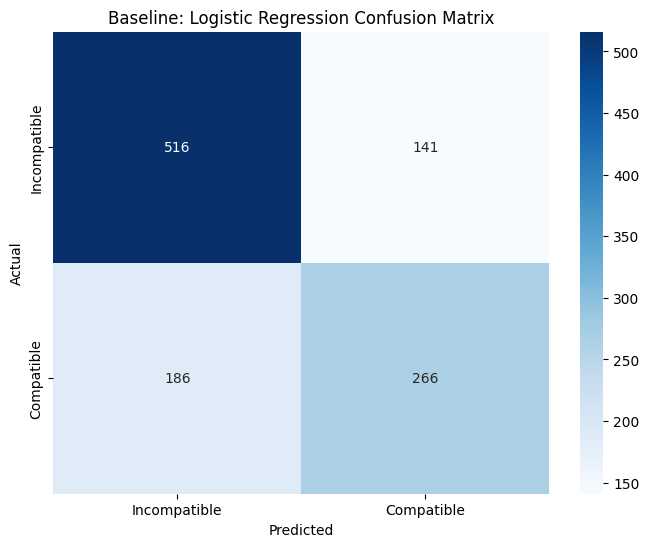

In [181]:
# train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# predict
lr_pred = lr_model.predict(X_test)

# accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Baseline Logistic Regression Test Accuracy: {lr_accuracy*100:.2f}%")

# confusion matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Incompatible', 'Compatible'],
            yticklabels=['Incompatible', 'Compatible'])
plt.title('Baseline: Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model B: Neural Network with Concatenation + Mean Embeddings
 

In [182]:
input_dim = X_train.shape[1]

model = Sequential([
    Dense(1024, input_shape=(input_dim,)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])


model.summary()

/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                │ (None, 1024)           │    10,486,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_69 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_70 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_71 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_72 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,183,617 (42.66 MB)

 Trainable params: 11,179,777 (42.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [183]:
# Compile Model B
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'] 
)

In [184]:
# Added early_stop to prevent overfitting by stopping when model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Added reduce_lr to reduce learning rate when training gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Train Model B
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.6230 - loss: 0.7339 - val_accuracy: 0.5961 - val_loss: 0.6493 - learning_rate: 0.0010
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6930 - loss: 0.5959 - val_accuracy: 0.5961 - val_loss: 0.6770 - learning_rate: 0.0010
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7267 - loss: 0.5401 - val_accuracy: 0.5961 - val_loss: 0.7810 - learning_rate: 0.0010
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7477 - loss: 0.5084 - val_accuracy: 0.5991 - val_loss: 0.7352 - learning_rate: 0.0010
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7925 - loss: 0.4341 - val_accuracy: 0.5961 - val_loss: 0.9472 - learning_rate: 5.0000e-04
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8328 - loss: 0.3853 - val_accuracy: 0.5991 - val_loss: 1.0187 - learning_rate: 5.0000e-04
Epoch 7/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8549 - loss: 0.3299 -

Model B Test Accuracy: 59.24%


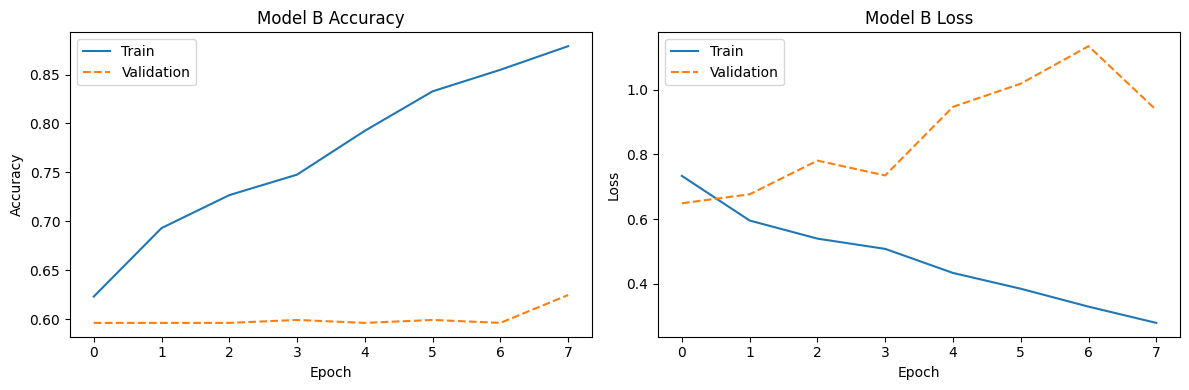

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


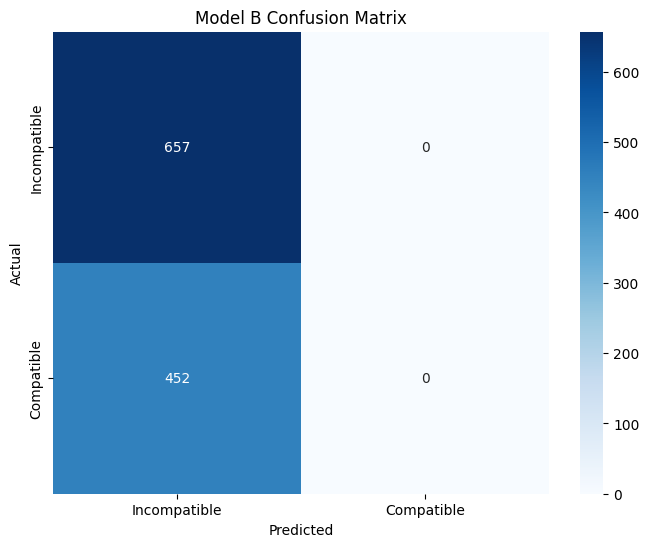

In [185]:
# Evaluate Model B

# accuracy
result = model.evaluate(X_test, y_test, verbose=0)
print(f"Model B Test Accuracy: {result[1]*100:.2f}%")

# accuracy plot 
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], linestyle='--', label='Validation')
plt.title('Model B Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation')
plt.title('Model B Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm_b = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_b,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Incompatible', 'Compatible'],
    yticklabels=['Incompatible', 'Compatible']
)
plt.title('Model B Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model C: Neural Network with Concatenation + Mean + Pairwise Embedding

To improve the accuracy of our classification model, we experimented with a new pairwise embedding approach. This method adds pairwise difference vectors between clothing item embeddings so the model can better learn relationships between pieces in an outfit.

In [186]:
# Load saved embeddings
X_c = np.load('X_pairwise_embeddings.npy')
y_c = np.load('y_pairwise_labels.npy')

In [187]:
# Train/Test Split

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

In [188]:
input_dim_c = X_c_train.shape[1]

model_c = Sequential([
    Dense(1024, input_shape=(input_dim_c,), kernel_regularizer=l2(1e-4)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, kernel_regularizer=l2(1e-4)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, kernel_regularizer=l2(1e-4)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model_c.summary()

/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 1024)           │    23,069,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_73 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_74 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_75 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_76 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,766,529 (90.66 MB)

 Trainable params: 23,762,689 (90.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [189]:
# Compile Model C
model_c.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [190]:
# Train Model C

# early_stop_c prevents overfitting by stopping when model stops improving
early_stop_c = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    min_delta=1e-4
)

# reduce_lr_c reduces learning rate when training gets stuck
reduce_lr_c = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_c = model_c.fit(
    X_c_train, y_c_train,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop_c, reduce_lr_c]
)

Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step - accuracy: 0.6431 - loss: 1.0615 - val_accuracy: 0.6982 - val_loss: 1.0061 - learning_rate: 0.0010
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.7084 - loss: 0.9690 - val_accuracy: 0.6862 - val_loss: 0.9797 - learning_rate: 0.0010
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.7363 - loss: 0.9145 - val_accuracy: 0.7027 - val_loss: 0.9494 - learning_rate: 0.0010
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.7790 - loss: 0.8470 - val_accuracy: 0.6907 - val_loss: 0.9750 - learning_rate: 0.0010
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.8066 - loss: 0.7907 - val_accuracy: 0.6862 - val_loss: 0.9847 - learning_rate: 0.0010
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.8321 - loss: 0.7371 - val_accuracy: 0.6877 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 7/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.8867 - loss: 0.6590 -

Model C Test Accuracy: 69.79%


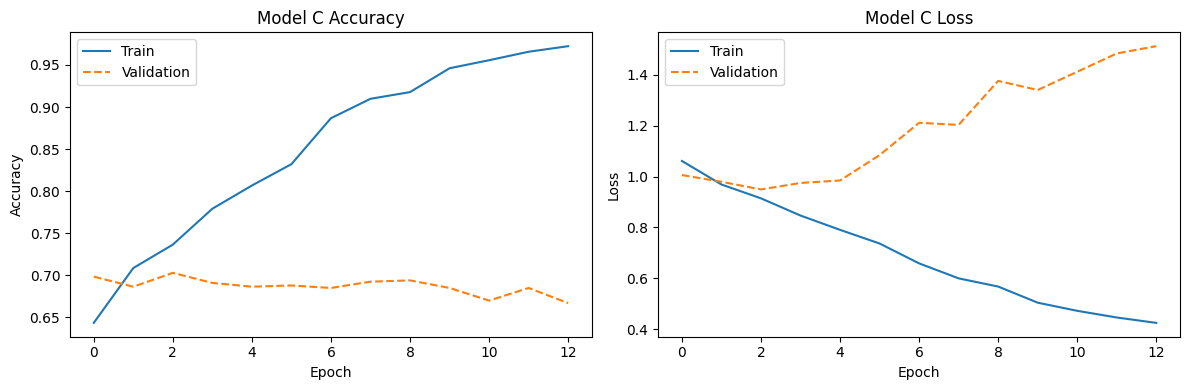

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


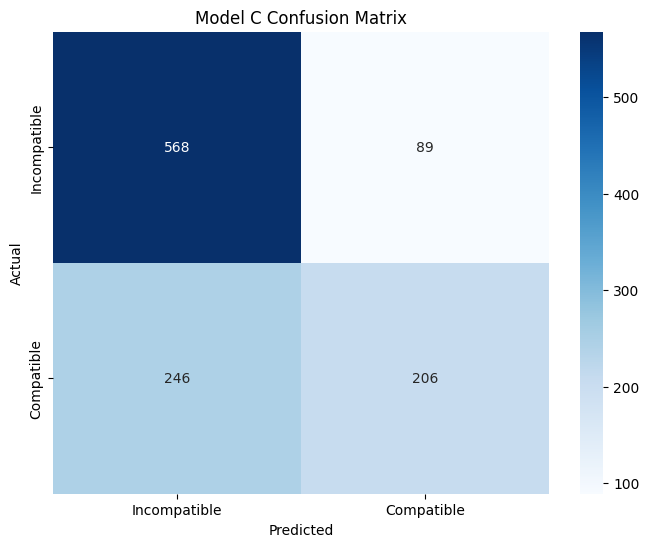

In [191]:
# Evaluate Model C

# accuracy
result_c = model_c.evaluate(X_c_test, y_c_test, verbose=0)
print(f"Model C Test Accuracy: {result_c[1]*100:.2f}%")

# accuracy plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_c.history['accuracy'], label='Train')
plt.plot(history_c.history['val_accuracy'], linestyle='--', label='Validation')
plt.title('Model C Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# loss plot
plt.subplot(1, 2, 2)
plt.plot(history_c.history['loss'], label='Train')
plt.plot(history_c.history['val_loss'], linestyle='--', label='Validation')
plt.title('Model C Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# confusion matrix
y_pred_c = (model_c.predict(X_c_test) > 0.5).astype(int)
cm_c = confusion_matrix(y_c_test, y_pred_c)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_c,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Incompatible', 'Compatible'],
    yticklabels=['Incompatible', 'Compatible']
)
plt.title('Model C Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Results

### Model A vs. Model B vs. Model C Comparison

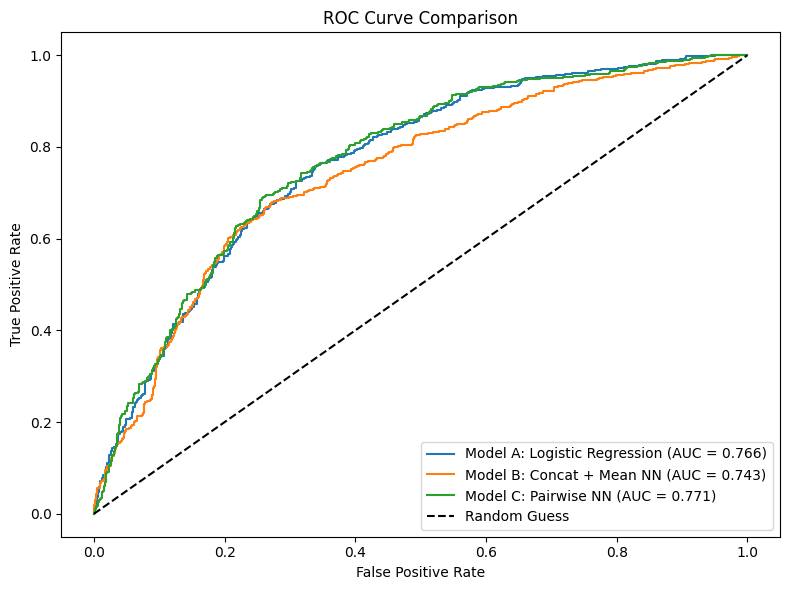

In [192]:
# ROC Curve Comparison

# Model A: Logistic Regression baseline
y_prob_a = lr_model.predict_proba(X_test)[:, 1]

# Model B: Neural network with concat + mean embeddings
y_prob_b = model.predict(X_test, verbose=0).flatten()

# Model C: Neural network with pairwise embeddings
y_prob_c = model_c.predict(X_c_test, verbose=0).flatten()

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_true, y_prob in [
    ("Model A: Logistic Regression", y_test, y_prob_a),
    ("Model B: Concat + Mean NN", y_test, y_prob_b),
    ("Model C: Pairwise NN", y_c_test, y_prob_c),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [198]:
# Classification Report Comparison

reports = [
    ("Model A: Logistic Regression", y_test, y_prob_a),
    ("Model B: Concat + Mean NN", y_test, y_prob_b),
    ("Model C: Pairwise NN", y_c_test, y_prob_c),
]

for name, y_true, y_prob in reports:
    y_pred_report = (y_prob > 0.5).astype(int)

    print("\n" + "="*70)
    print(name)
    print("="*70)

    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred_report,
            target_names=["Incompatible", "Compatible"],
            output_dict=True,
            zero_division=0
        )
    ).transpose()

    display(report_df)


Model A: Logistic Regression


,precision,recall,f1-score,support
Incompatible,0.735043,0.785388,0.759382,657.00000
Compatible,0.653563,0.588496,0.619325,452.00000
accuracy,0.705140,0.705140,0.705140,0.70514
macro avg,0.694303,0.686942,0.689353,1109.00000
weighted avg,0.701834,0.705140,0.702298,1109.00000



Model B: Concat + Mean NN


,precision,recall,f1-score,support
Incompatible,0.592426,1.000000,0.744054,657.000000
Compatible,0.000000,0.000000,0.000000,452.000000
accuracy,0.592426,0.592426,0.592426,0.592426
macro avg,0.296213,0.500000,0.372027,1109.000000
weighted avg,0.350968,0.592426,0.440797,1109.000000



Model C: Pairwise NN


,precision,recall,f1-score,support
Incompatible,0.697789,0.864536,0.772264,657.000000
Compatible,0.698305,0.455752,0.551539,452.000000
accuracy,0.697926,0.697926,0.697926,0.697926
macro avg,0.698047,0.660144,0.661902,1109.000000
weighted avg,0.697999,0.697926,0.682302,1109.000000


In [199]:
# Summary Table

auc_a = roc_auc_score(y_test, y_prob_a)
auc_b = roc_auc_score(y_test, y_prob_b)
auc_c = roc_auc_score(y_c_test, y_prob_c)

summary_df = pd.DataFrame({
    "Model": [
        "Model A",
        "Model B",
        "Model C"
    ],
    "Model Type": [
        "Logistic Regression",
        "Neural Network",
        "Neural Network"
    ],
    "Input Representation": [
        "Concat + average embedding",
        "Concat + average embedding",
        "Concat + average + pairwise differences"
    ],
    "Test Accuracy": [
        f"{lr_accuracy*100:.2f}%",
        f"{result[1]*100:.2f}%",
        f"{result_c[1]*100:.2f}%"
    ],
    "AUC-ROC": [
        f"{auc_a:.4f}",
        f"{auc_b:.4f}",
        f"{auc_c:.4f}"
    ]
})

summary_df.style.hide(axis="index")

Model,Model Type,Input Representation,Test Accuracy,AUC-ROC
Model A,Logistic Regression,Concat + average embedding,70.51%,0.7660
Model B,Neural Network,Concat + average embedding,59.24%,0.7435
Model C,Neural Network,Concat + average + pairwise differences,69.79%,0.7710


### Visualize Correct/Wrong Predictions

Since Model C achieved the strongest overall performance, we will use it for the correct and incorrect prediction visualizations below.

Actual Compatible, Predicted Compatible


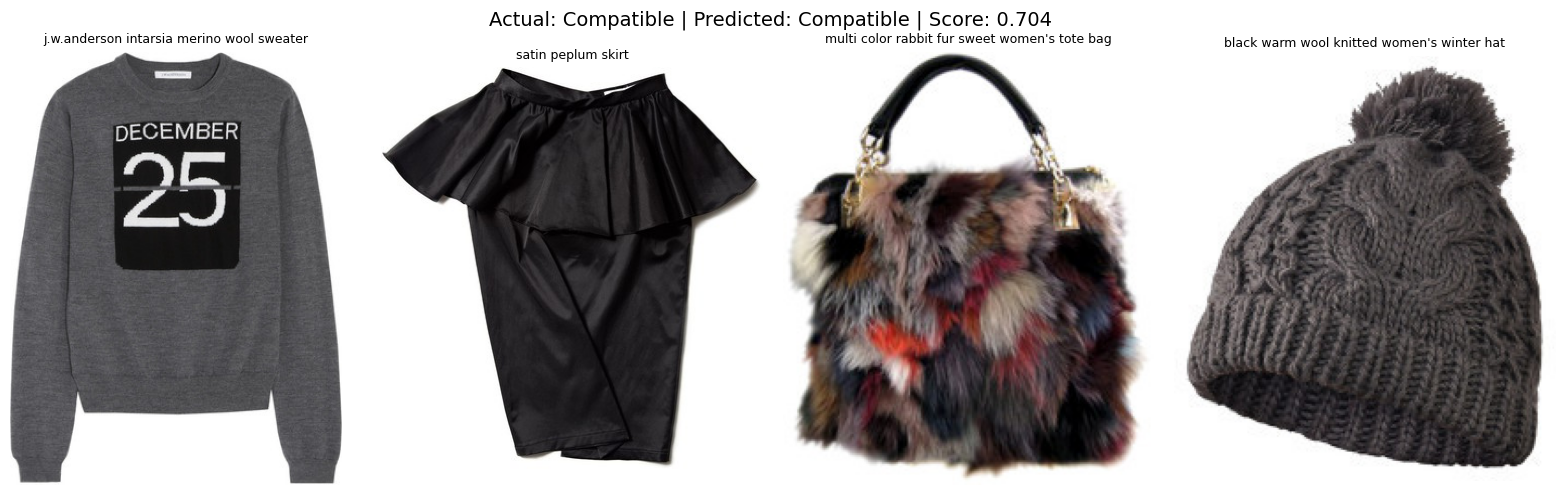

Actual Incompatible, Predicted Incompatible


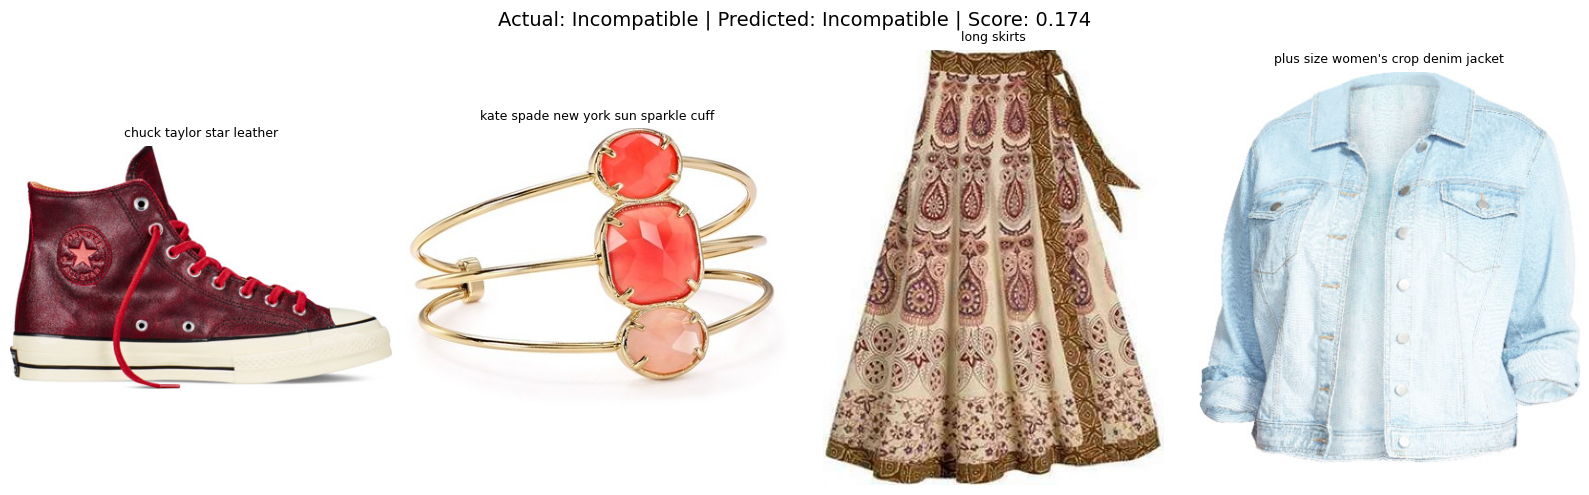

Actual Compatible, Predicted Incompatible


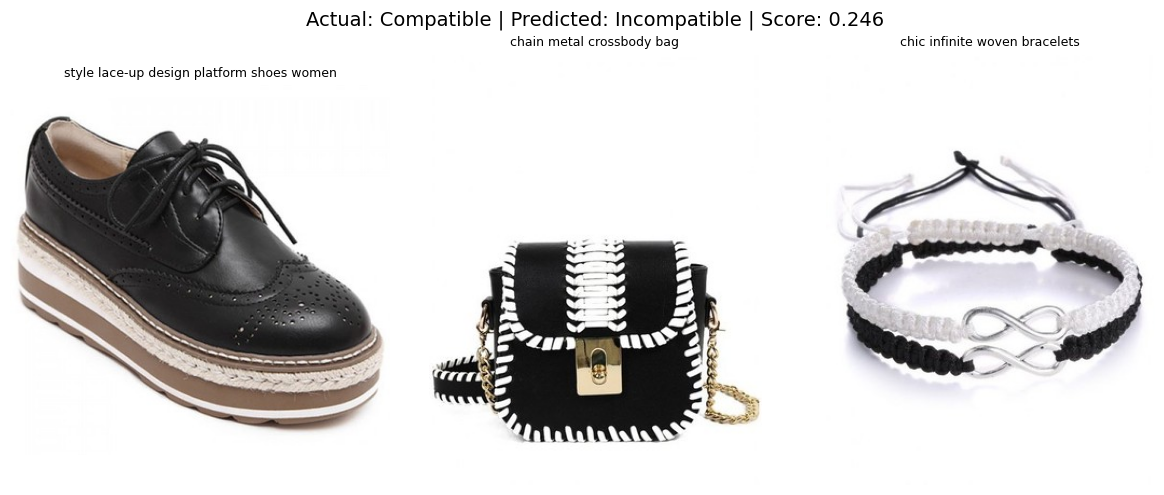

Actual Incompatible, Predicted Compatible


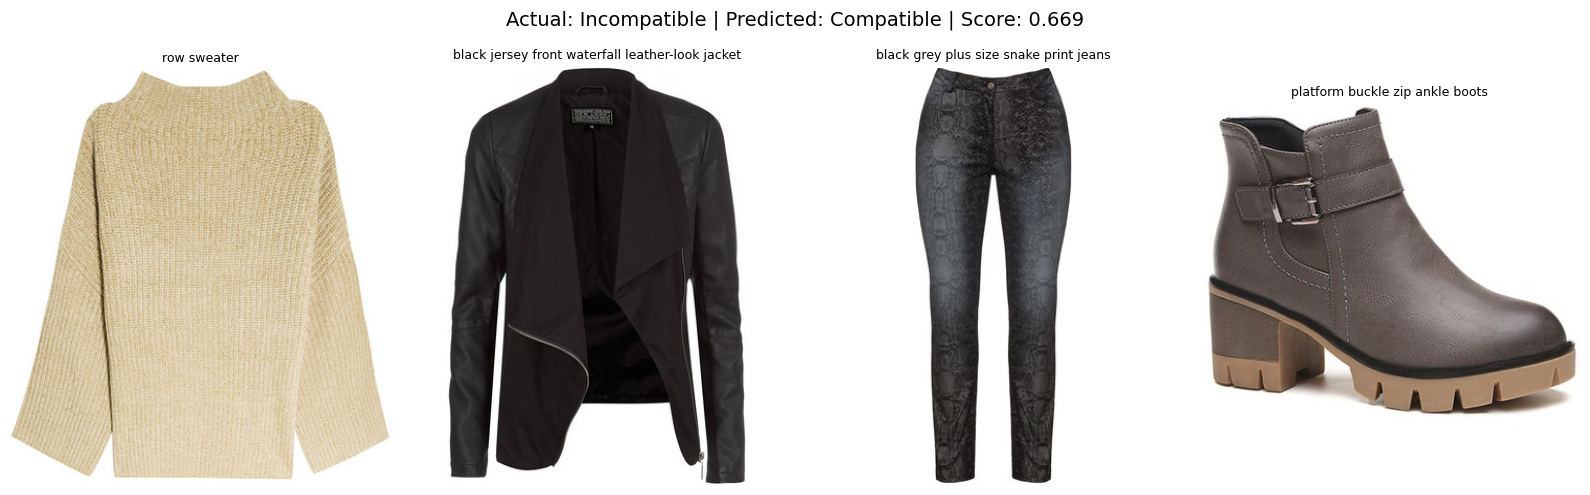

In [200]:
# Reconnect Model C test predictions to the original outfit item IDs

outfit_item_ids, outfit_labels = [], []

for line in lines:
    parts = line.strip().split()

    # Match Model C filtering: only keep outfits with at least 2 available item images
    if len(parts) >= 2 and sum(1 for p in parts[1:] if p in image_lookup) >= 2:
        outfit_labels.append(int(parts[0]))
        outfit_item_ids.append(parts[1:])

_, item_ids_c_test, _, _ = train_test_split(
    np.array(outfit_item_ids, dtype=object),
    np.array(outfit_labels),
    test_size=0.2,
    random_state=42,
    stratify=outfit_labels
)

# Model C predictions
y_prob_c = model_c.predict(X_c_test, verbose=0).flatten()
y_pred_c = (y_prob_c > 0.5).astype(int)


def get_available_items(index, min_count=3):
    """
    Used for Model C prediction visualization.
    Filters an outfit's item IDs to only those with images in image_lookup,
    returning None if fewer than min_count images are available.
    """
    items = [i for i in item_ids_c_test[index] if i in image_lookup]
    return items if len(items) >= min_count else None


def show_prediction(index):
    """
    Used for Model C prediction visualization.
    Displays up to 4 item images for a test outfit alongside its actual label,
    predicted label, and compatibility score.
    """
    items = get_available_items(index)

    if items is None:
        return

    items = items[:4]

    actual_label = "Compatible" if y_c_test[index] == 1 else "Incompatible"
    predicted_label = "Compatible" if y_pred_c[index] == 1 else "Incompatible"

    _, axes = plt.subplots(1, len(items), figsize=(4 * len(items), 5))

    if len(items) == 1:
        axes = [axes]

    for ax, item_id in zip(axes, items):
        ax.imshow(Image.open(image_lookup[item_id]))
        ax.set_title(name_lookup.get(item_id, item_id), fontsize=9, wrap=True)
        ax.axis("off")

    plt.suptitle(
        f"Actual: {actual_label} | Predicted: {predicted_label} | Score: {y_prob_c[index]:.3f}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


# Display one example from each prediction type for Model C
cases = {
    "Actual Compatible, Predicted Compatible": (y_c_test == 1) & (y_pred_c == 1),
    "Actual Incompatible, Predicted Incompatible": (y_c_test == 0) & (y_pred_c == 0),
    "Actual Compatible, Predicted Incompatible": (y_c_test == 1) & (y_pred_c == 0),
    "Actual Incompatible, Predicted Compatible": (y_c_test == 0) & (y_pred_c == 1),
}

for label, mask in cases.items():
    print(label)

    found_example = False

    for index in np.where(mask)[0]:
        if get_available_items(index):
            show_prediction(index)
            found_example = True
            break

    if not found_example:
        print("No example found with enough available item images.")

## Test Your Own Outfit! - Human Parsing & Compatibility Prediction

To test your own outfit, upload a clear full-body photo and name it `"my_outfit.jpeg". The human parsing model will automatically detect and crop clothing items from the photo, convert those crops into embeddings, and use the trained outfit compatibility model to predict whether the outfit is compatible or incompatible.

For the final outfit testing pipeline, we will use Model C to predict whether the uploaded outfit is compatible or incompatible because it achieved the strongest performance in our model comparison.

Loading human parsing model…


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Model ready.


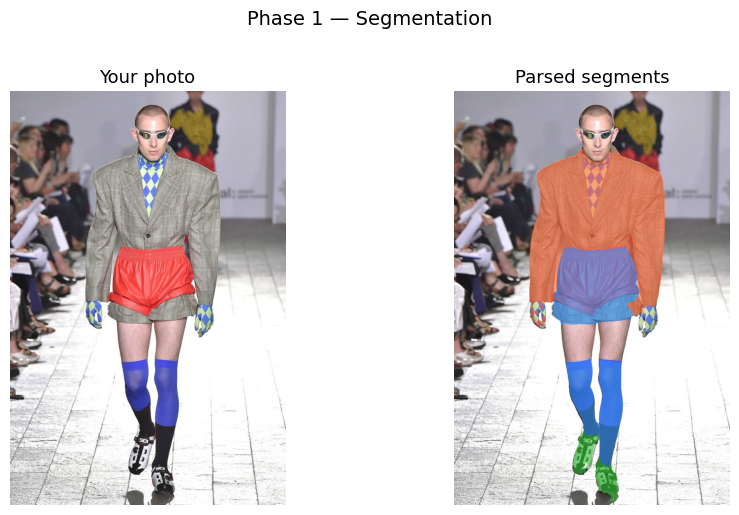

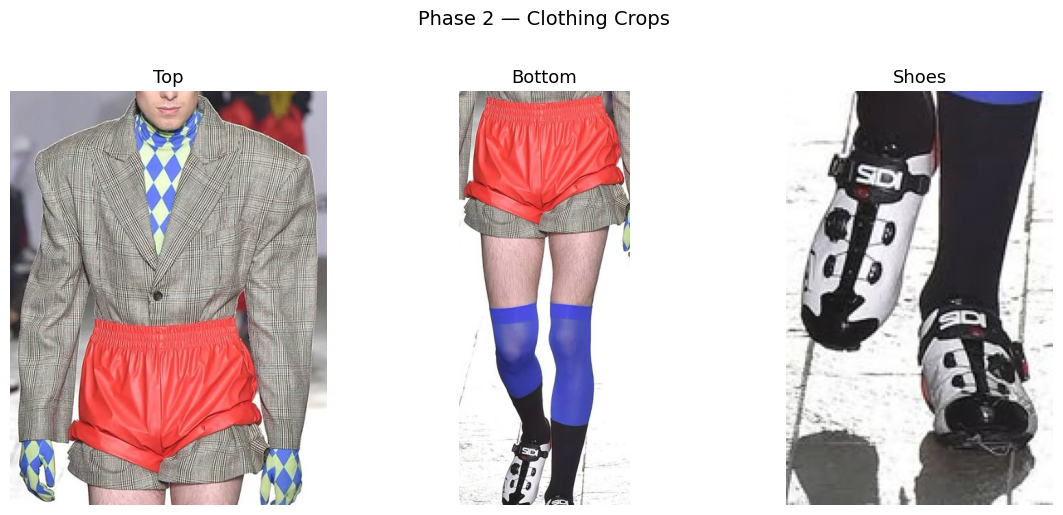

Detected: ['top', 'bottom', 'shoes']
Embedding shape: (22528,)

Compatibility score : 0.418
Verdict             : Incompatible


In [210]:
# Trained on the ATR dataset; labels used for human parsing
ATR_LABELS = {
    0:  "background",
    1:  "hat",
    2:  "hair",
    3:  "sunglasses",
    4:  "top",
    5:  "skirt",
    6:  "pants",
    7:  "dress",
    8:  "belt",
    9:  "left_shoe",
    10: "right_shoe",
    11: "face",
    12: "left_leg",
    13: "right_leg",
    14: "left_arm",
    15: "right_arm",
    16: "bag",
}

# Logical clothing groups we care about
CATEGORY_GROUPS = {
    "top":    {4},
    "bottom": {5, 6},
    "dress":  {7},
    "shoes":  {9, 10},
}

# Load SegFormer fine-tuned on ATR
PARSER_MODEL = "mattmdjaga/segformer_b2_clothes"

print("Loading human parsing model…")
processor = SegformerImageProcessor.from_pretrained(PARSER_MODEL)
parser = SegformerForSemanticSegmentation.from_pretrained(PARSER_MODEL)
parser.eval()
print("Model ready.")


def parse_clothing(pil_image):
    """
    Used for the human parsing pipeline.
    Runs SegFormer on a PIL image to produce a per-pixel ATR label map,
    where each pixel is assigned a clothing category, body part, or background ID.
    """
    inputs = processor(images=pil_image, return_tensors="pt")

    with torch.no_grad():
        logits = parser(**inputs).logits

    H, W = pil_image.height, pil_image.width

    upsampled = F.interpolate(
        logits,
        size=(H, W),
        mode="bilinear",
        align_corners=False
    )

    label_map = upsampled.argmax(dim=1).squeeze(0).numpy().astype(np.int32)

    return label_map


def visualise_parse(pil_image, label_map):
    """
    Used for debugging and visualization.
    Overlays color-coded clothing segments onto the original image:
    orange = top, blue = bottom, purple = dress, green = shoes.
    """
    colours = {
        4:  (255, 100,  50),  # top — orange
        5:  (50, 150, 255),   # skirt — blue
        6:  (50, 150, 255),   # pants — blue
        7:  (150, 50, 255),   # dress — purple
        9:  (50, 200, 50),    # left shoe — green
        10: (50, 200, 50),    # right shoe — green
    }

    overlay = np.array(pil_image.convert("RGB"), dtype=np.float32)

    for label_id, colour in colours.items():
        mask = label_map == label_id

        for c, v in enumerate(colour):
            overlay[mask, c] = overlay[mask, c] * 0.4 + v * 0.6

    return Image.fromarray(overlay.astype(np.uint8))


def extract_clothing_crops(pil_image, label_map, apply_mask=False, padding=10):
    """
    Used for the human parsing pipeline.
    Crops each detected clothing category from the image using bounding boxes
    from the label map.
    """
    img_arr = np.array(pil_image.convert("RGB"))
    H, W = label_map.shape
    crops = {}

    for category, label_ids in CATEGORY_GROUPS.items():
        mask = np.zeros((H, W), dtype=bool)

        for lid in label_ids:
            mask |= label_map == lid

        if not mask.any():
            continue

        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]

        y0 = max(rows[0] - padding, 0)
        y1 = min(rows[-1] + padding, H - 1)
        x0 = max(cols[0] - padding, 0)
        x1 = min(cols[-1] + padding, W - 1)

        crop = img_arr[y0:y1 + 1, x0:x1 + 1].copy()

        if apply_mask:
            crop_mask = mask[y0:y1 + 1, x0:x1 + 1]
            crop[~crop_mask] = 0

        crops[category] = Image.fromarray(crop)

    return crops


def get_image_embedding_from_pil(pil_image):
    """
    Converts a PIL clothing crop into a normalized ResNet50 embedding.
    """
    img = pil_image.convert("RGB").resize((224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    embedding = base_model.predict(img_array, verbose=0)[0]

    norm = np.linalg.norm(embedding)

    if norm > 0:
        embedding = embedding / norm

    return embedding


def get_outfit_pairwise_embedding_from_photo(image_path, apply_mask=False, max_items=4):
    """
    Converts an uploaded outfit photo into the same concat + mean + pairwise
    difference embedding format used by Model C.

    Model C representation:
        4 item embeddings x 2048
        + 1 mean embedding x 2048
        + 6 pairwise difference embeddings x 2048
        = 22528 total features
    """
    pil_img = Image.open(image_path).convert("RGB")
    label_map = parse_clothing(pil_img)

    crops = extract_clothing_crops(
        pil_img,
        label_map,
        apply_mask=apply_mask
    )

    if not crops:
        raise ValueError("No clothing items were detected in the uploaded photo.")

    embeddings = []

    # Keep a consistent item order for the outfit representation
    for category in ["top", "bottom", "dress", "shoes"]:
        if category in crops:
            embeddings.append(get_image_embedding_from_pil(crops[category]))

    if not embeddings:
        raise ValueError("No usable clothing crops were found.")

    dimension = embeddings[0].shape[0]

    # Calculate mean before padding so missing item slots do not affect the mean
    mean_emb = np.mean(embeddings, axis=0)

    # Pad with zero vectors if fewer than max_items are detected
    while len(embeddings) < max_items:
        embeddings.append(np.zeros(dimension))

    # Cut off if more than max_items are detected
    embeddings = embeddings[:max_items]

    # Create pairwise difference vectors for all item pairs
    pairs = []

    for i in range(max_items):
        for j in range(i + 1, max_items):
            pairs.append(embeddings[i] - embeddings[j])

    outfit_embedding = np.concatenate(embeddings + [mean_emb] + pairs)

    return outfit_embedding, crops


def test_my_outfit(image_path, apply_mask=False):
    """
    Used for end-to-end outfit compatibility testing with Model C.

    Pipeline:
        1. Upload a full-body outfit photo.
        2. Use SegFormer to parse/crop clothing items.
        3. Convert each crop into a ResNet50 embedding.
        4. Build the Model C pairwise outfit embedding.
        5. Use Model C to predict compatible or incompatible.
    """
    pil_img = Image.open(image_path).convert("RGB")
    label_map = parse_clothing(pil_img)

    crops = extract_clothing_crops(
        pil_img,
        label_map,
        apply_mask=apply_mask
    )

    if not crops:
        print("No clothing detected — try a clearer full-body photo.")
        return

    # Phase 1: show original image and segmentation overlay
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(pil_img)
    axes[0].set_title("Your photo", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(visualise_parse(pil_img, label_map))
    axes[1].set_title("Parsed segments", fontsize=13)
    axes[1].axis("off")

    plt.suptitle("Phase 1 — Segmentation", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Phase 2: show individual clothing crops
    n = len(crops)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, (cat, crop_img) in zip(axes, crops.items()):
        ax.imshow(crop_img)
        ax.set_title(cat.capitalize(), fontsize=13)
        ax.axis("off")

    plt.suptitle("Phase 2 — Clothing Crops", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Detected: {list(crops.keys())}")

    try:
        embedding, _ = get_outfit_pairwise_embedding_from_photo(
            image_path,
            apply_mask=apply_mask
        )

        print(f"Embedding shape: {embedding.shape}")

        score = model_c.predict(embedding[np.newaxis], verbose=0)[0][0]
        label = "Compatible" if score > 0.5 else "Incompatible"

        print(f"\nCompatibility score : {score:.3f}")
        print(f"Verdict             : {label}")

    except Exception as e:
        print(f"\n(Classifier not available yet: {e})")


# Replace "my_outfit.jpeg" with the filename of your uploaded outfit photo
test_my_outfit("my_outfit.jpeg")